# Phonon DOS and Mode-Projection Analysis

This notebook analyzes phonon frequencies and displacement eigenvectors extracted from frozen-phonon calculations for Li-deficient Ta-doped LLZO/LLZTO garnet structures.

The notebook uses processed `phonons.npz` files and corresponding VASP `POSCAR` structures stored in `data/processed/`.

The analysis focuses on:

- total phonon density of states;
- mean phonon DOS over 50 ps, 75 ps, and 100 ps MD snapshots;
- element-projected phonon DOS;
- bond-projected phonon DOS;
- interpretation of Li–O-related vibrational features.

The main total PDOS comparison is averaged over the three MD snapshot times. Element- and bond-projected analyses are shown for the 100 ps structures to provide a clearer mode-character interpretation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read
from ase.neighborlist import neighbor_list

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "pdos"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

systems = {
    "Li6p5": {
        "label": r"Li$_{6.5}$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{12}$",
        "folders": {
            "50 ps": "Li6p5_50ps",
            "75 ps": "Li6p5_75ps",
            "100 ps": "Li6p5_100ps",
        },
    },
    "Li5p5": {
        "label": r"Li$_{5.5}$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{11.5}$",
        "folders": {
            "50 ps": "Li5p5_50ps",
            "75 ps": "Li5p5_75ps",
            "100 ps": "Li5p5_100ps",
        },
    },
    "Li5": {
        "label": r"Li$_5$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{11.25}$",
        "folders": {
            "50 ps": "Li5_50ps",
            "75 ps": "Li5_75ps",
            "100 ps": "Li5_100ps",
        },
    },
}

elements_to_project = ["Li", "La", "Zr", "Ta", "O"]
bond_pairs_to_project = [("Li", "O"), ("La", "O"), ("Zr", "O"), ("Ta", "O")]

frequency_range = (0, 900)
interpretation_range = (200, 600)

## Input files

Each processed structure folder contains:

| File | Role |
|---|---|
| `POSCAR` | Reference structure used for phonon-mode analysis |
| `phonons.npz` | NumPy archive containing phonon frequencies and displacement eigenvectors |

The `phonons.npz` files contain:

| Array | Meaning |
|---|---|
| `wavenumbers` | phonon frequencies in cm⁻¹ |
| `displacements` | mass-scaled displacement vectors |
| `undivided_displacements` | normalized displacement eigenvectors before mass division |

Imaginary modes are excluded from the DOS analysis by retaining only modes with nonzero real frequencies.

In [3]:
class PhononData:
    """Container for phonon frequencies, eigenvectors, and structure data."""

    def __init__(self, path):
        self.path = Path(path)
        self.poscar_path = self.path / "POSCAR"
        self.phonon_path = self.path / "phonons.npz"

        if not self.poscar_path.exists():
            raise FileNotFoundError(f"Could not find POSCAR: {self.poscar_path}")
        if not self.phonon_path.exists():
            raise FileNotFoundError(f"Could not find phonons.npz: {self.phonon_path}")

        self.atoms = read(self.poscar_path)
        self.symbols = np.array(self.atoms.get_chemical_symbols())

        data = np.load(self.phonon_path)

        self.complex_wavenumbers = data["wavenumbers"]
        self.all_displacements = data["displacements"]
        self.all_undivided_displacements = data["undivided_displacements"]

        # Keep only real, nonzero-frequency modes.
        valid_mask = np.array([np.real(wn) != 0 for wn in self.complex_wavenumbers])

        self.wavenumbers = np.real(self.complex_wavenumbers[valid_mask])
        self.displacements = self.all_displacements[valid_mask]
        self.undivided_displacements = self.all_undivided_displacements[valid_mask]

    def dos(self, weights=None, x=None, smearing=13.0, frequency_range=(0, 900), n_points=2000):
        """Calculate Gaussian-broadened DOS with optional mode weights."""
        if x is None:
            x = np.linspace(frequency_range[0], frequency_range[1], n_points)

        if weights is None:
            weights = np.ones_like(self.wavenumbers, dtype=float)
        else:
            weights = np.asarray(weights, dtype=float)

        y = np.zeros_like(x, dtype=float)

        for wn, weight in zip(self.wavenumbers, weights):
            gaussian = np.exp(-((x - wn) ** 2) / (2 * smearing**2))
            y += weight * gaussian

        if np.max(y) > 0:
            y = y / np.max(y)

        return x, y

    def element_weights(self, element):
        """Estimate mode weights from displacement amplitudes of a selected element."""
        mask = self.symbols == element

        if not np.any(mask):
            raise ValueError(f"Element {element} not found in structure.")

        # Sum squared displacement amplitudes for selected atoms.
        weights = np.sum(self.undivided_displacements[:, mask, :] ** 2, axis=(1, 2))
        return weights

    def bond_weights(self, element_a, element_b, cutoff=3.0):
        """Estimate mode weights from bond-length changes for a selected pair.

        This is a qualitative mode-character metric. It measures how strongly
        selected pair distances change under each phonon displacement pattern.
        """
        symbols = self.symbols
        positions = self.atoms.get_positions()
        cell = self.atoms.get_cell()
        pbc = self.atoms.get_pbc()

        i_list, j_list, offsets = neighbor_list("ijS", self.atoms, cutoff)

        selected_pairs = []
        for i, j, offset in zip(i_list, j_list, offsets):
            pair = {symbols[i], symbols[j]}
            if pair == {element_a, element_b}:
                selected_pairs.append((i, j, offset))

        if len(selected_pairs) == 0:
            raise ValueError(f"No {element_a}-{element_b} pairs found with cutoff={cutoff} Å.")

        weights = []

        for mode_disp in self.undivided_displacements:
            total_change = 0.0

            for i, j, offset in selected_pairs:
                r_i = positions[i]
                r_j = positions[j] + np.dot(offset, cell)

                d0 = np.linalg.norm(r_j - r_i)

                r_i_disp = r_i + mode_disp[i]
                r_j_disp = r_j + mode_disp[j]

                d1 = np.linalg.norm(r_j_disp - r_i_disp)
                total_change += abs(d1 - d0)

            weights.append(total_change)

        return np.array(weights)

In [4]:
phonon_data = {}

for system_name, system_info in systems.items():
    phonon_data[system_name] = {}

    for time_label, folder_name in system_info["folders"].items():
        folder_path = DATA_DIR / folder_name
        phonon_data[system_name][time_label] = PhononData(folder_path)

print("Loaded phonon datasets:")
for system_name, time_data in phonon_data.items():
    for time_label, obj in time_data.items():
        n_modes = len(obj.wavenumbers)
        n_atoms = len(obj.atoms)
        f_min = obj.wavenumbers.min()
        f_max = obj.wavenumbers.max()
        print(
            f"{system_name:5s} | {time_label:6s} | "
            f"{n_atoms:3d} atoms | {n_modes:3d} real modes | "
            f"{f_min:8.2f}–{f_max:8.2f} cm^-1"
        )

Loaded phonon datasets:
Li6p5 | 50 ps  |  94 atoms | 279 real modes |    45.58–  733.96 cm^-1
Li6p5 | 75 ps  |  94 atoms | 269 real modes |    21.14–  962.49 cm^-1
Li6p5 | 100 ps |  94 atoms | 273 real modes |    19.26–  944.66 cm^-1
Li5p5 | 50 ps  |  88 atoms | 261 real modes |    47.13–  803.72 cm^-1
Li5p5 | 75 ps  |  88 atoms | 251 real modes |    15.20–  928.79 cm^-1
Li5p5 | 100 ps |  88 atoms | 254 real modes |    19.89–  951.87 cm^-1
Li5   | 50 ps  |  85 atoms | 252 real modes |    27.52–  741.46 cm^-1
Li5   | 75 ps  |  85 atoms | 245 real modes |    20.74–  931.51 cm^-1
Li5   | 100 ps |  85 atoms | 247 real modes |    11.03–  821.30 cm^-1


In [5]:
summary_rows = []

for system_name, time_data in phonon_data.items():
    for time_label, obj in time_data.items():
        modes_in_interpretation_range = np.sum(
            (obj.wavenumbers >= interpretation_range[0])
            & (obj.wavenumbers <= interpretation_range[1])
        )

        summary_rows.append(
            {
                "system": system_name,
                "time": time_label,
                "n_atoms": len(obj.atoms),
                "n_real_modes": len(obj.wavenumbers),
                "min_frequency_cm1": obj.wavenumbers.min(),
                "max_frequency_cm1": obj.wavenumbers.max(),
                "n_modes_200_600": modes_in_interpretation_range,
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df

,system,time,n_atoms,n_real_modes,min_frequency_cm1,max_frequency_cm1,n_modes_200_600
0,Li6p5,50 ps,94,279,45.581307,733.958826,195
1,Li6p5,75 ps,94,269,21.142423,962.492518,168
2,Li6p5,100 ps,94,273,19.259301,944.662655,175
3,Li5p5,50 ps,88,261,47.126748,803.723788,174
4,Li5p5,75 ps,88,251,15.202680,928.792154,151
5,Li5p5,100 ps,88,254,19.886172,951.868287,157
6,Li5,50 ps,85,252,27.515519,741.461622,171
7,Li5,75 ps,85,245,20.743238,931.508415,150
8,Li5,100 ps,85,247,11.033644,821.302732,149


## Total phonon density of states

The total phonon density of states is calculated by applying Gaussian broadening to the discrete phonon frequencies.

For the main comparison across Li contents, the DOS is calculated for the 50 ps, 75 ps, and 100 ps structures and then averaged for each composition. This gives a compact comparison of the representative vibrational features for each Li content.

In [6]:
def mean_total_dos_for_system(
    system_name,
    xlim=(0, 900),
    smearing=13.0,
    normalize_individual=True,
    normalize_mean=True,
):
    """Calculate mean total PDOS over 50, 75, and 100 ps snapshots."""
    x_common = np.linspace(xlim[0], xlim[1], 2000)
    spectra = []

    for time_label in ["50 ps", "75 ps", "100 ps"]:
        obj = phonon_data[system_name][time_label]
        x, y = obj.dos(
            x=x_common,
            smearing=smearing,
            frequency_range=xlim,
            n_points=2000,
        )

        if normalize_individual and np.max(y) > 0:
            y = y / np.max(y)

        spectra.append(y)

    spectra = np.array(spectra)
    y_mean = spectra.mean(axis=0)
    y_std = spectra.std(axis=0)

    if normalize_mean and np.max(y_mean) > 0:
        scale = np.max(y_mean)
        y_mean = y_mean / scale
        y_std = y_std / scale

    return x_common, y_mean, y_std


def plot_mean_total_pdos(
    xlim=(0, 900),
    smearing=13.0,
    show_std=False,
    save=True,
):
    """Plot mean total PDOS for all Li contents."""
    fig, ax = plt.subplots(figsize=(8, 5))

    for system_name in ["Li6p5", "Li5p5", "Li5"]:
        x, y_mean, y_std = mean_total_dos_for_system(
            system_name,
            xlim=xlim,
            smearing=smearing,
        )

        ax.plot(x, y_mean, label=systems[system_name]["label"])

        if show_std:
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Wavenumber / cm$^{-1}$")
    ax.set_ylabel("Mean normalized PDOS")
    ax.set_title("Mean total phonon DOS across MD snapshots")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        fig.savefig(FIGURE_DIR / "mean_total_pdos_by_li_content.png", dpi=300, bbox_inches="tight")

    return fig, ax

In [7]:
def mean_total_dos_for_system(
    system_name,
    xlim=(0, 900),
    smearing=13.0,
    normalize_individual=True,
    normalize_mean=True,
):
    """Calculate mean total PDOS over 50, 75, and 100 ps snapshots."""
    x_common = np.linspace(xlim[0], xlim[1], 2000)
    spectra = []

    for time_label in ["50 ps", "75 ps", "100 ps"]:
        obj = phonon_data[system_name][time_label]
        x, y = obj.dos(
            x=x_common,
            smearing=smearing,
            frequency_range=xlim,
            n_points=2000,
        )

        if normalize_individual and np.max(y) > 0:
            y = y / np.max(y)

        spectra.append(y)

    spectra = np.array(spectra)
    y_mean = spectra.mean(axis=0)
    y_std = spectra.std(axis=0)

    if normalize_mean and np.max(y_mean) > 0:
        scale = np.max(y_mean)
        y_mean = y_mean / scale
        y_std = y_std / scale

    return x_common, y_mean, y_std


def plot_mean_total_pdos(
    xlim=(0, 900),
    smearing=13.0,
    show_std=False,
    save=True,
):
    """Plot mean total PDOS for all Li contents."""
    fig, ax = plt.subplots(figsize=(8, 5))

    for system_name in ["Li6p5", "Li5p5", "Li5"]:
        x, y_mean, y_std = mean_total_dos_for_system(
            system_name,
            xlim=xlim,
            smearing=smearing,
        )

        ax.plot(x, y_mean, label=systems[system_name]["label"])

        if show_std:
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Wavenumber / cm$^{-1}$")
    ax.set_ylabel("Mean normalized PDOS")
    ax.set_title("Mean total phonon DOS across MD snapshots")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        fig.savefig(FIGURE_DIR / "mean_total_pdos_by_li_content.png", dpi=300, bbox_inches="tight")

    return fig, ax

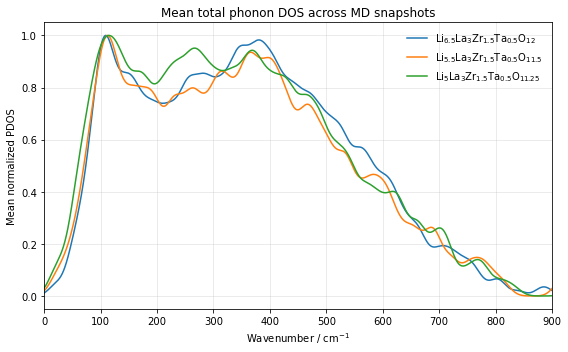

In [8]:
fig, ax = plot_mean_total_pdos(
    xlim=frequency_range,
    smearing=13.0,
    show_std=False,
)

In [9]:
def plot_element_projected_pdos(
    system_name,
    time_label="100 ps",
    elements=None,
    xlim=(0, 900),
    smearing=13.0,
    save=True,
):
    """Plot element-projected PDOS for one structure."""
    if elements is None:
        elements = elements_to_project

    obj = phonon_data[system_name][time_label]
    system_label = systems[system_name]["label"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for element in elements:
        weights = obj.element_weights(element)
        x, y = obj.dos(
            weights=weights,
            smearing=smearing,
            frequency_range=xlim,
            n_points=2000,
        )
        ax.plot(x, y, label=element)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Wavenumber / cm$^{-1}$")
    ax.set_ylabel("Normalized projected PDOS")
    ax.set_title(f"Element-projected PDOS for {system_label} ({time_label})")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        output_name = f"element_projected_pdos_{system_name}_{time_label.replace(' ', '')}.png"
        fig.savefig(FIGURE_DIR / output_name, dpi=300, bbox_inches="tight")

    return fig, ax

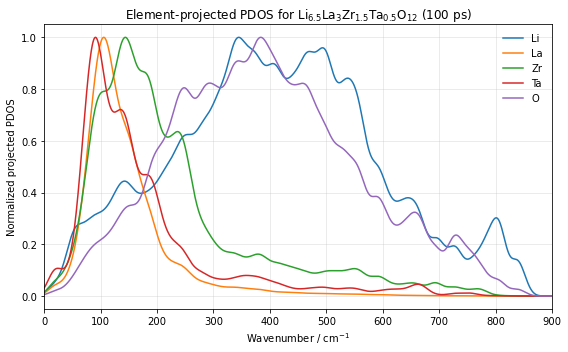

In [10]:
fig, ax = plot_element_projected_pdos(
    "Li6p5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
)

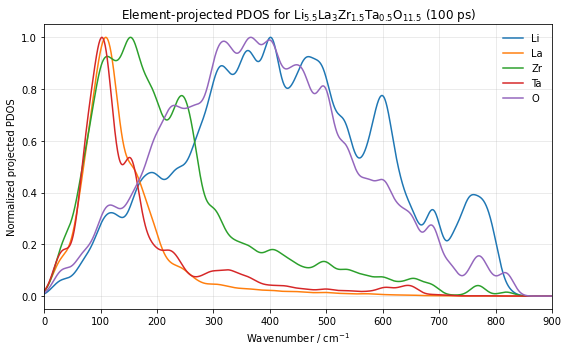

In [11]:
fig, ax = plot_element_projected_pdos(
    "Li5p5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
)

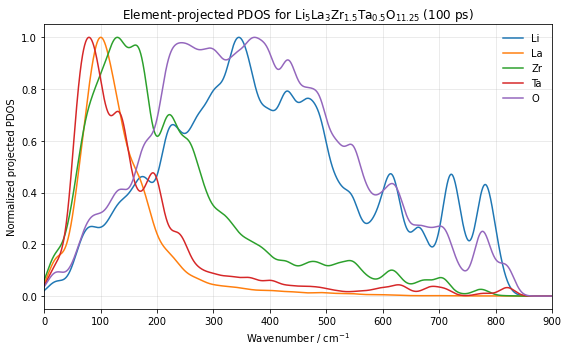

In [12]:
fig, ax = plot_element_projected_pdos(
    "Li5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
)

## Bond-projected phonon DOS

To support vibrational-mode interpretation, this section estimates bond-projected phonon DOS for selected cation–oxygen pairs.

For each phonon mode, the structure is displaced along the mode eigenvector and changes in selected bond lengths are accumulated. These values are then used as mode weights for constructing a projected DOS.

This is a qualitative mode-character analysis rather than a rigorous bond-resolved phonon decomposition.

In [13]:
def plot_bond_projected_pdos(
    system_name,
    time_label="100 ps",
    bond_pairs=None,
    xlim=(0, 900),
    smearing=13.0,
    cutoff=3.0,
    save=True,
):
    """Plot bond-projected PDOS for one structure."""
    if bond_pairs is None:
        bond_pairs = bond_pairs_to_project

    obj = phonon_data[system_name][time_label]
    system_label = systems[system_name]["label"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for element_a, element_b in bond_pairs:
        weights = obj.bond_weights(element_a, element_b, cutoff=cutoff)
        x, y = obj.dos(
            weights=weights,
            smearing=smearing,
            frequency_range=xlim,
            n_points=2000,
        )
        ax.plot(x, y, label=f"{element_a}–{element_b}")

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Wavenumber / cm$^{-1}$")
    ax.set_ylabel("Normalized bond-projected PDOS")
    ax.set_title(f"Bond-projected PDOS for {system_label} ({time_label})")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        output_name = f"bond_projected_pdos_{system_name}_{time_label.replace(' ', '')}.png"
        fig.savefig(FIGURE_DIR / output_name, dpi=300, bbox_inches="tight")

    return fig, ax

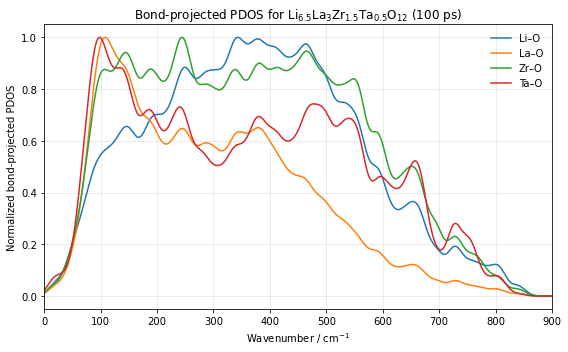

In [14]:
fig, ax = plot_bond_projected_pdos(
    "Li6p5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
    cutoff=3.0,
)

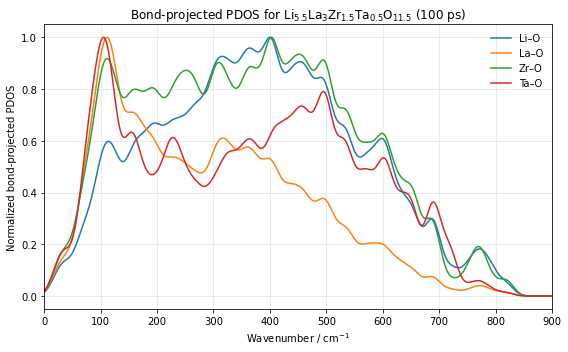

In [15]:
fig, ax = plot_bond_projected_pdos(
    "Li5p5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
    cutoff=3.0,
)

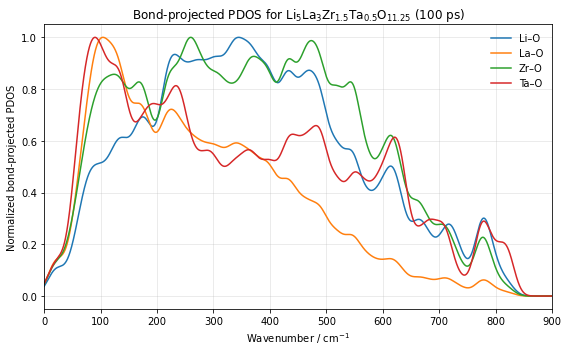

In [16]:
fig, ax = plot_bond_projected_pdos(
    "Li5",
    time_label="100 ps",
    xlim=frequency_range,
    smearing=13.0,
    cutoff=3.0,
)